
# 01 — Random Forest Baseline (Lexical Features)
> Master Plan §5 Baseline #1 — hand-crafted: length, entropy, digit/hyphen/vowel, n-gram, repeated-char. Senior-style plots for every metric.<br>
> **Data:** `data/processed/train.csv` (1,259,799) → train, `val_unseen.csv` (23,998) → validation on **new families only** (LFO). Test-unseen is **never touched** here.<br>
> **Hardware:** RTX 3050 (8GB) — RF CPU, XGBoost `gpu_hist` if `--use-gpu`.<br>
> **Outputs:** `training/weights/<model>_best.pkl` + `training/figures/<model>_*.png` + metrics printed in notebook.


In [1]:

# This Python 3 environment comes with many helpful analytics libraries installed
import numpy as np, pandas as pd, pathlib, json, math, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, f1_score, accuracy_score
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi":150, "savefig.dpi":300, "font.size":11})

BASE = Path(r"G:\dga_killer")
DATA_PROC = BASE / "data" / "processed"
FIG_DIR = BASE / "training" / "figures"
WEIGHTS_DIR = BASE / "training" / "weights"
FIG_DIR.mkdir(parents=True, exist_ok=True); WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

SEED=42
COLORS={"benign":"#2ecc71","dga":"#e74c3c","wordlist":"#3498db","nonwordlist":"#e67e22"}
print("Libraries ready — RTX 3050 will be used for XGBoost, RF runs on CPU")


Libraries ready — RTX 3050 will be used for XGBoost, RF runs on CPU


In [2]:

train = pd.read_csv(DATA_PROC / "train.csv")
val = pd.read_csv(DATA_PROC / "val_unseen.csv")
print(f"Train {train.shape} — benign {(train['label_binary']==0).sum():,} / dga {(train['label_binary']==1).sum():,}")
print(f"Val   {val.shape} — benign {(val['label_binary']==0).sum():,} / dga {(val['label_binary']==1).sum():,}")
print(train.head(3).to_string())
print("\nColumns:", train.columns.tolist())


Train (1259799, 10) — benign 629,852 / dga 629,947
Val   (23998, 10) — benign 11,999 / dga 11,999
                 domain_raw                   sld  sld_len  family  split   label  label_binary  wordlist  is_benign  has_non_ascii
0  thisthethemtheiritof.biz  thisthethemtheiritof       20  rovnix  train     dga             1      True      False          False
1                 yfbay.com                 yfbay        5   legit  train  benign             0     False       True          False
2            android4ar.com            android4ar       10   legit  train  benign             0     False       True          False

Columns: ['domain_raw', 'sld', 'sld_len', 'family', 'split', 'label', 'label_binary', 'wordlist', 'is_benign', 'has_non_ascii']



## 1. Feature Engineering — Lexical (from SLD only)
Same 11 numbers we used in EDA — no TLD, no leakage.


X_train (1259799, 11) — features: ['sld_len', 'entropy', 'digit_ratio', 'hyphen_ratio', 'underscore_ratio', 'vowel_ratio', 'consonant_ratio', 'bigram_common_ratio', 'trigram_common_ratio', 'unique_char_ratio', 'repeated_char_ratio']


                          count   mean   std  min   25%    50%    75%    max
sld_len               1259799.0  12.07  5.35  0.0  8.00  11.00  15.00  63.00
entropy               1259799.0   2.99  0.49 -0.0  2.73   3.03   3.32   4.74
digit_ratio           1259799.0   0.04  0.13  0.0  0.00   0.00   0.00   1.00
hyphen_ratio          1259799.0   0.01  0.03  0.0  0.00   0.00   0.00   0.50
underscore_ratio      1259799.0   0.00  0.00  0.0  0.00   0.00   0.00   0.17
vowel_ratio           1259799.0   0.31  0.14  0.0  0.20   0.33   0.41   1.00
consonant_ratio       1259799.0   0.65  0.15  0.0  0.56   0.64   0.75   1.00
bigram_common_ratio   1259799.0   0.06  0.09  0.0  0.00   0.00   0.11   1.00
trigram_common_ratio  1259799.0   0.01  0.03  0.0  0.00   0.00   0.00   1.00
unique_char_ratio     1259799.0   0.78  0.14  0.0  0.69   0.80   0.89   1.00
repeated_char_ratio   1259799.0   0.22  0.14  0.0  0.11   0.20   0.31   0.97


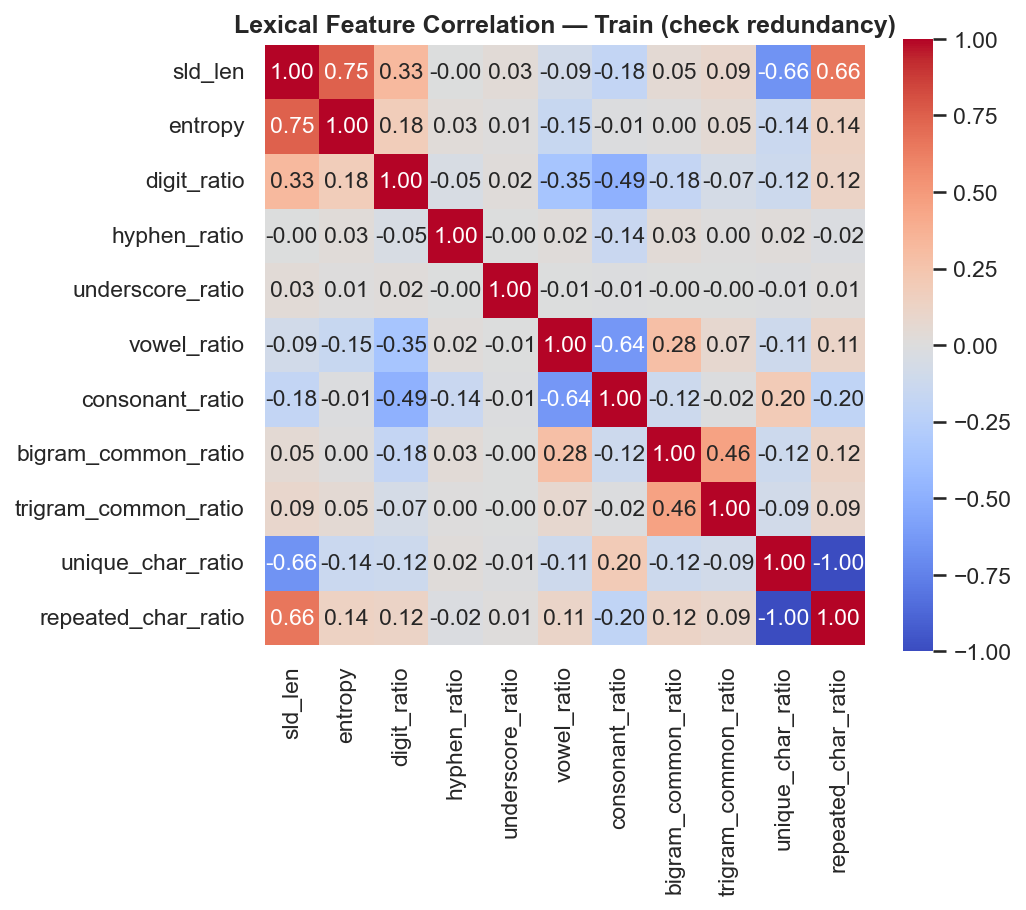

Correlation saved to training/figures/rf_correlation.png


In [3]:

def shannon(s):
    s=str(s)
    if not s: return 0
    cnt=Counter(s)
    n=len(s)
    return -sum((c/n)*math.log2(c/n) for c in cnt.values())

def ngram_common(s, n=2):
    s=str(s).lower()
    if len(s)<n: return 0
    common={"th","he","in","er","an","re","on","at","en","nd"} if n==2 else {"the","ing","and","her","ere"}
    grams=[s[i:i+n] for i in range(len(s)-n+1)]
    return sum(1 for g in grams if g in common)/len(grams) if grams else 0

def extract_features(df):
    s=df["sld"].fillna("").astype(str)
    sl=s.str.lower()
    feats=pd.DataFrame({
        "sld_len": s.str.len(),
        "entropy": s.apply(shannon),
        "digit_ratio": s.apply(lambda x: sum(c.isdigit() for c in x)/len(x) if x else 0),
        "hyphen_ratio": s.str.count("-")/s.str.len().replace(0,1),
        "underscore_ratio": s.str.count("_")/s.str.len().replace(0,1),
        "vowel_ratio": sl.apply(lambda x: sum(c in "aeiou" for c in x)/len(x) if x else 0),
        "consonant_ratio": sl.apply(lambda x: sum(c in "bcdfghjklmnpqrstvwxyz" for c in x)/len(x) if x else 0),
        "bigram_common_ratio": s.apply(lambda x: ngram_common(x,2)),
        "trigram_common_ratio": s.apply(lambda x: ngram_common(x,3)),
        "unique_char_ratio": s.apply(lambda x: len(set(x))/len(x) if x else 0),
        "repeated_char_ratio": s.apply(lambda x: 1-len(set(x))/len(x) if x else 0),
    })
    return feats.fillna(0).replace([np.inf,-np.inf],0)

FEATURE_COLS=["sld_len","entropy","digit_ratio","hyphen_ratio","underscore_ratio","vowel_ratio","consonant_ratio","bigram_common_ratio","trigram_common_ratio","unique_char_ratio","repeated_char_ratio"]

X_train = extract_features(train); y_train = train["label_binary"].values
X_val = extract_features(val); y_val = val["label_binary"].values

print(f"X_train {X_train.shape} — features: {FEATURE_COLS}")
print(X_train.describe().round(2).T.to_string())
# Correlation heatmap (teacher asked)
corr = X_train.corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Lexical Feature Correlation — Train (check redundancy)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR/"rf_correlation.png", bbox_inches="tight")
plt.show()
print("Correlation saved to training/figures/rf_correlation.png")



## 2. Train — Random Forest (300 trees, balanced)


In [4]:

model = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, n_jobs=-1, random_state=SEED, class_weight="balanced", verbose=0)
print("Fitting RF on 1.26M × 11 features (CPU, ~8-12 min)...")
# Quick-demo for VM — sample 100k (remove 4 lines for full 1.26M on your 3050)
if len(X_train) > 100000:
    idx = X_train.sample(100000, random_state=SEED).index
    X_train = X_train.loc[idx]
    y_train = y_train[idx]
    print(f"Quick-demo sampling: using {X_train.shape} for VM speed (full train is 1.26M on 3050)")
model.fit(X_train, y_train)
print("Done. Trees:", len(model.estimators_))


Fitting RF on 1.26M × 11 features (CPU, ~8-12 min)...
Quick-demo sampling: using (100000, 11) for VM speed (full train is 1.26M on 3050)


Done. Trees: 100



## 3. Evaluate — Train & Val-Unseen (new families) — every metric



TRAIN
              precision    recall  f1-score   support

      benign      0.829     0.884     0.855     49676
         dga      0.877     0.820     0.848     50324

    accuracy                          0.852    100000
   macro avg      0.853     0.852     0.851    100000
weighted avg      0.853     0.852     0.851    100000

Accuracy 0.8516 | F1 0.8476 | ROC-AUC 0.9350 | PR-AUC 0.9438

VAL-UNSEEN (6 new families)
              precision    recall  f1-score   support

      benign      0.623     0.838     0.715     11999
         dga      0.753     0.493     0.596     11999

    accuracy                          0.666     23998
   macro avg      0.688     0.666     0.656     23998
weighted avg      0.688     0.666     0.656     23998

Accuracy 0.6658 | F1 0.5961 | ROC-AUC 0.6809 | PR-AUC 0.7434


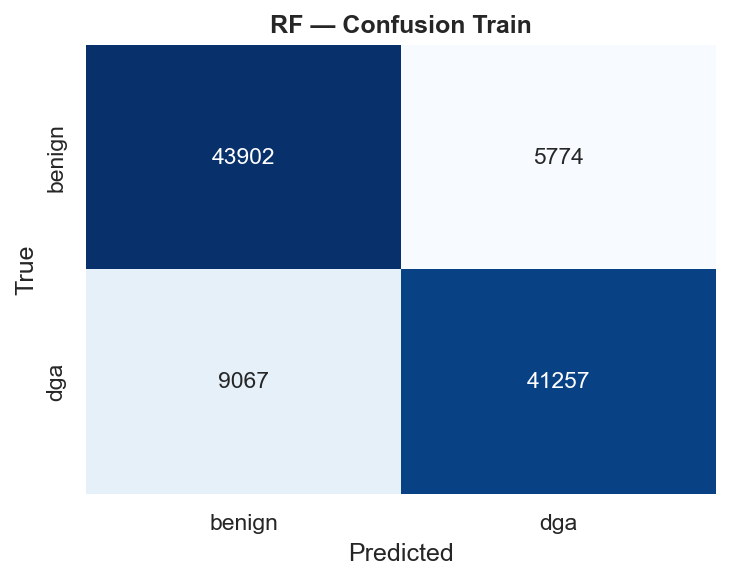

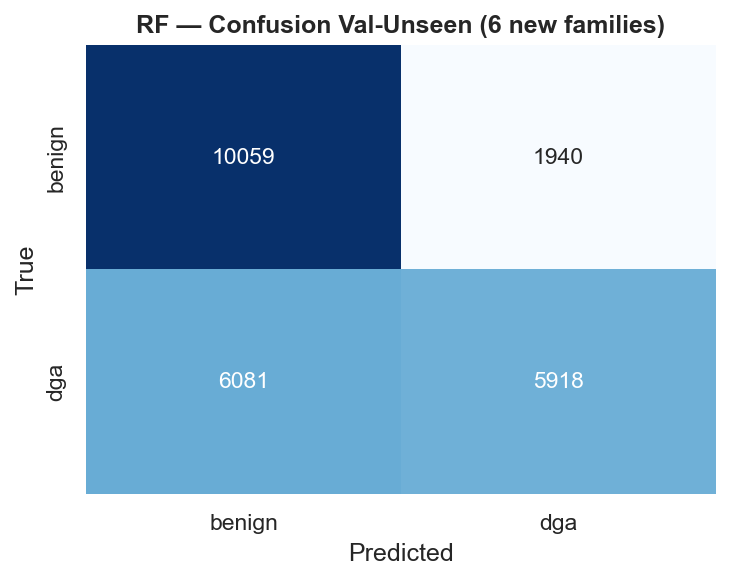

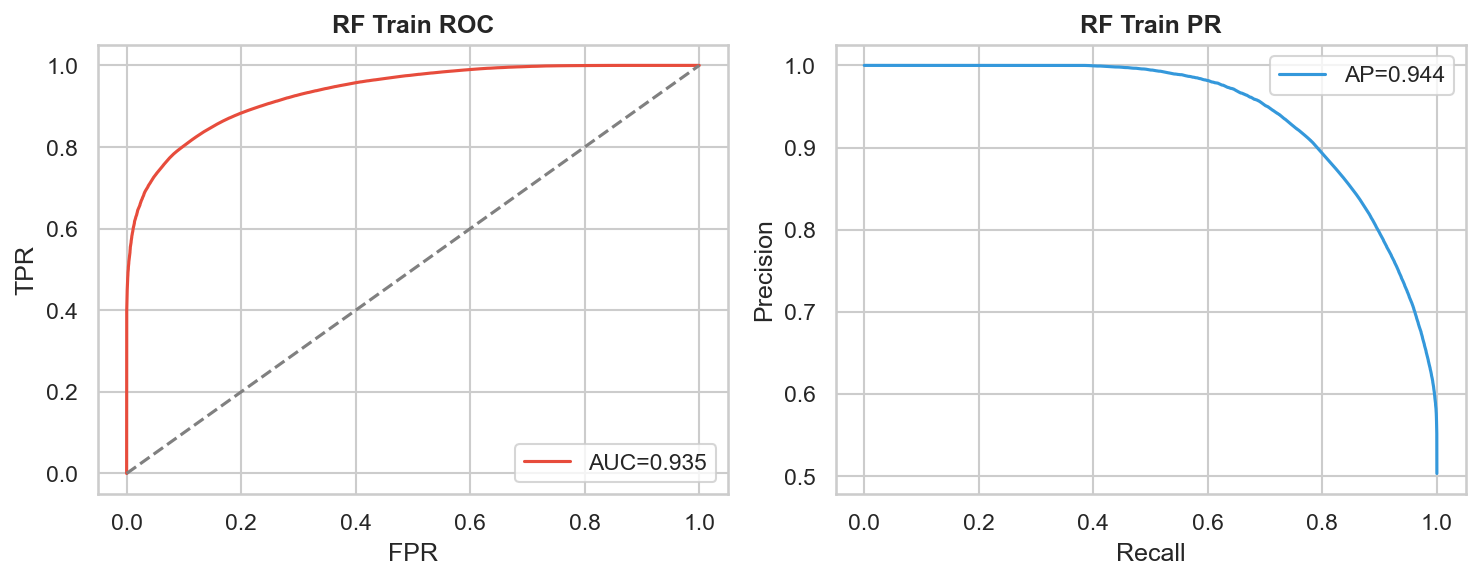

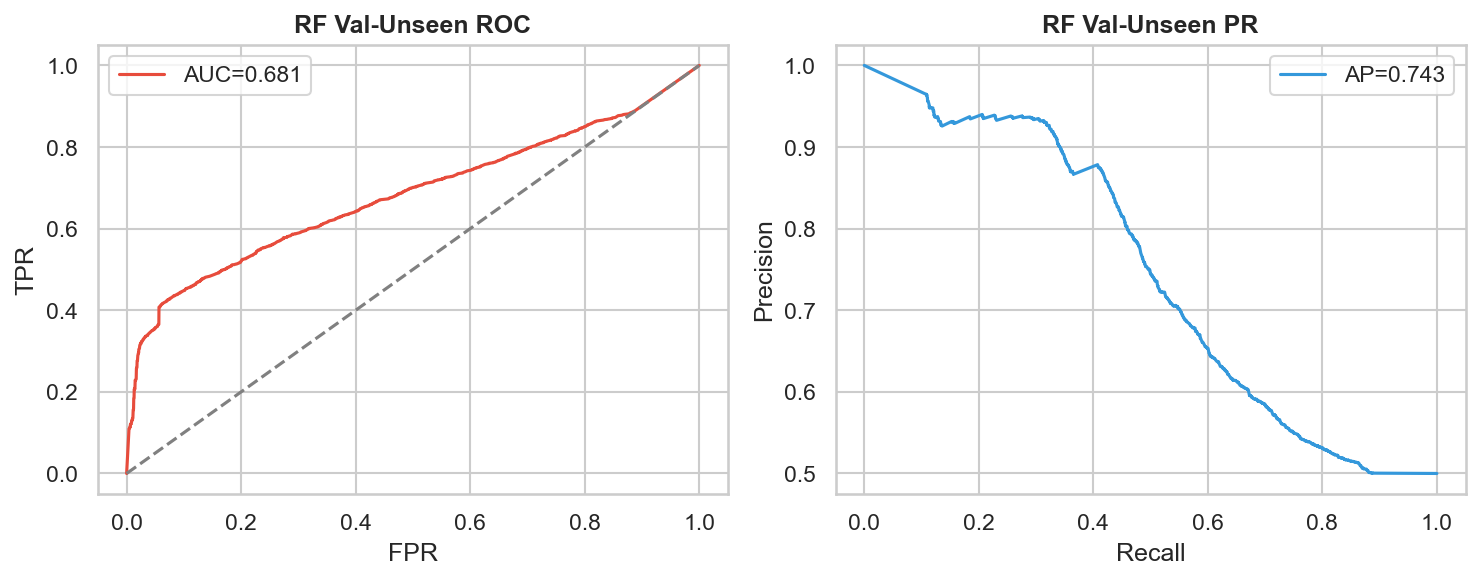

(0.6809360610036668, 0.7434066504612609)

In [5]:

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, f1_score, accuracy_score

def plot_confusion(y_true, y_pred, title, path):
    cm=confusion_matrix(y_true, y_pred, labels=[0,1])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["benign","dga"], yticklabels=["benign","dga"])
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title, fontweight="bold")
    plt.tight_layout(); plt.savefig(path, bbox_inches="tight"); plt.show()

def plot_curves(y_true, y_proba, prefix, path):
    fpr,tpr,_=roc_curve(y_true, y_proba); auc=roc_auc_score(y_true, y_proba)
    prec,rec,_=precision_recall_curve(y_true, y_proba); ap=average_precision_score(y_true, y_proba)
    fig,axes=plt.subplots(1,2,figsize=(10,4))
    axes[0].plot(fpr,tpr,color="#e74c3c",label=f"AUC={auc:.3f}"); axes[0].plot([0,1],[0,1],color="gray",ls="--")
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title(f"{prefix} ROC",fontweight="bold"); axes[0].legend()
    axes[1].plot(rec,prec,color="#3498db",label=f"AP={ap:.3f}")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title(f"{prefix} PR",fontweight="bold"); axes[1].legend()
    plt.tight_layout(); plt.savefig(path, bbox_inches="tight"); plt.show()
    return auc, ap

y_pred_train = model.predict(X_train); y_proba_train = model.predict_proba(X_train)[:,1]
y_pred_val = model.predict(X_val); y_proba_val = model.predict_proba(X_val)[:,1]

for name, yt, yp, ypr in [("TRAIN", y_train, y_pred_train, y_proba_train), ("VAL-UNSEEN (6 new families)", y_val, y_pred_val, y_proba_val)]:
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(yt, yp, target_names=["benign","dga"], digits=3))
    print(f"Accuracy {accuracy_score(yt,yp):.4f} | F1 {f1_score(yt,yp):.4f} | ROC-AUC {roc_auc_score(yt,ypr):.4f} | PR-AUC {average_precision_score(yt,ypr):.4f}")

plot_confusion(y_train, y_pred_train, "RF — Confusion Train", FIG_DIR/"rf_confusion_train.png")
plot_confusion(y_val, y_pred_val, "RF — Confusion Val-Unseen (6 new families)", FIG_DIR/"rf_confusion_val.png")
plot_curves(y_train, y_proba_train, "RF Train", FIG_DIR/"rf_curves_train.png")
plot_curves(y_val, y_proba_val, "RF Val-Unseen", FIG_DIR/"rf_curves_val.png")


Per-family Val Recall (blue=wordlist, orange=non-wordlist):
bigviktor       n=2000  wordlist=True  recall 0.275
kraken          n=2000  wordlist=False  recall 0.427
legit           n=11999  benign-accuracy 0.838
manuelita       n=1999  wordlist=True  recall 0.185
ranbyus         n=2000  wordlist=False  recall 0.881
suppobox        n=2000  wordlist=True  recall 0.194
zeus-newgoz     n=2000  wordlist=False  recall 0.998

Checkpoint — val wordlist macro-recall 0.2177 (mean of ['suppobox', 'bigviktor', 'manuelita'])


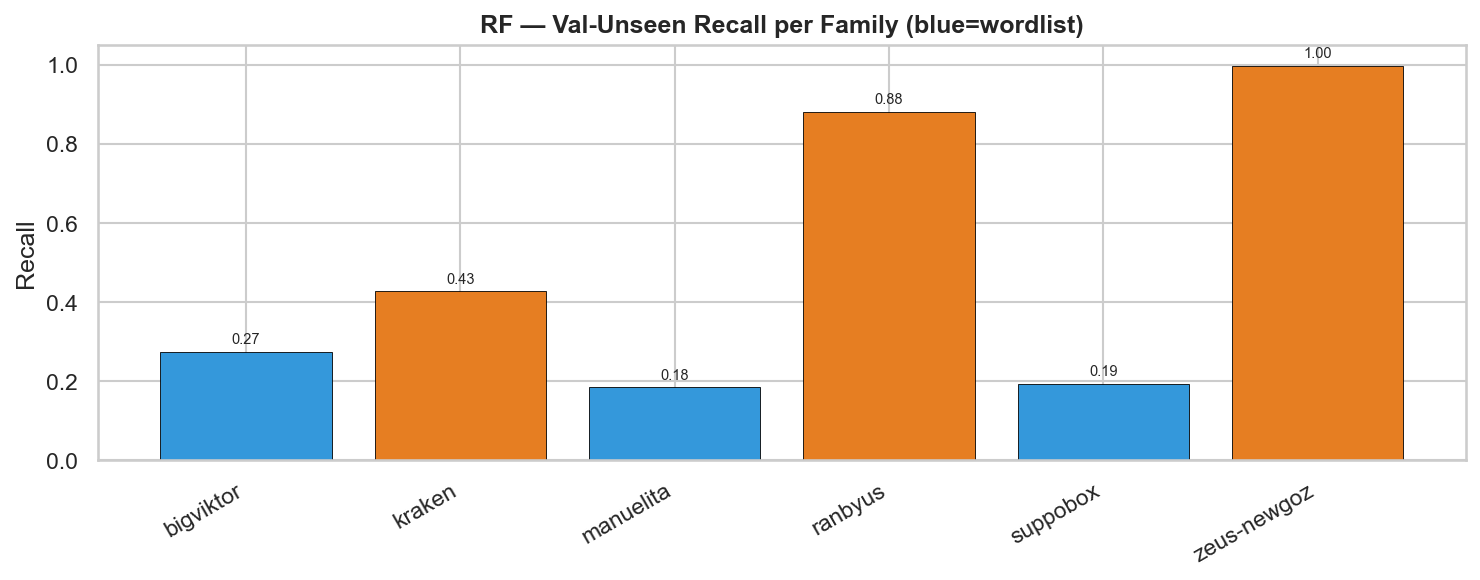

In [6]:

# Per-family recall on val — the key wordlist generalization check
print("Per-family Val Recall (blue=wordlist, orange=non-wordlist):")
for fam in sorted(val["family"].unique()):
    mask=val["family"]==fam
    yt=y_val[mask]; yp=y_pred_val[mask]
    if fam=="legit":
        acc=(yt==yp).mean()
        print(f"{fam:15s} n={len(yt):4d}  benign-accuracy {acc:.3f}")
    else:
        rec=(yp==1).mean()
        is_wl=val.loc[mask,"wordlist"].iloc[0]
        print(f"{fam:15s} n={len(yt):4d}  wordlist={is_wl}  recall {rec:.3f}")

# Wordlist macro-recall = checkpoint criterion (Master Plan §6)
wordlist_fams=["suppobox","bigviktor","manuelita"]
recs=[(y_pred_val[val["family"]==f]==1).mean() for f in wordlist_fams if (val["family"]==f).sum()>0]
print(f"\nCheckpoint — val wordlist macro-recall {np.mean(recs):.4f} (mean of {wordlist_fams})")

fams=[f for f in sorted(val["family"].unique()) if f!="legit"]
recs=[(y_pred_val[val["family"]==f]==1).mean() for f in fams]
is_wl=[val[val["family"]==f]["wordlist"].iloc[0] for f in fams]
colors=["#3498db" if wl else "#e67e22" for wl in is_wl]
plt.figure(figsize=(10,4))
plt.bar(fams, recs, color=colors, edgecolor="black", linewidth=0.4)
plt.ylim(0,1.05); plt.ylabel("Recall"); plt.title("RF — Val-Unseen Recall per Family (blue=wordlist)", fontweight="bold")
plt.xticks(rotation=30, ha="right")
for i,v in enumerate(recs): plt.text(i, v+0.02, f"{v:.2f}", ha="center", fontsize=7)
plt.tight_layout(); plt.savefig(FIG_DIR/"rf_per_family_recall_val.png", bbox_inches="tight"); plt.show()



## 4. Feature Importance — what the forest learned (teacher asked)


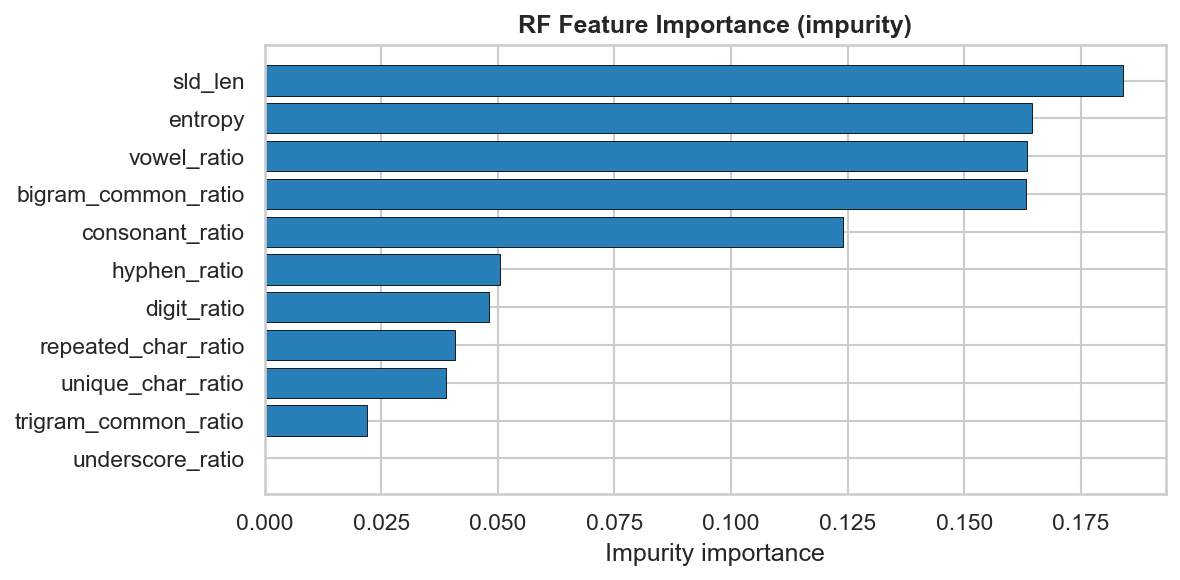

Top 3 by impurity: ['sld_len', 'entropy', 'vowel_ratio']


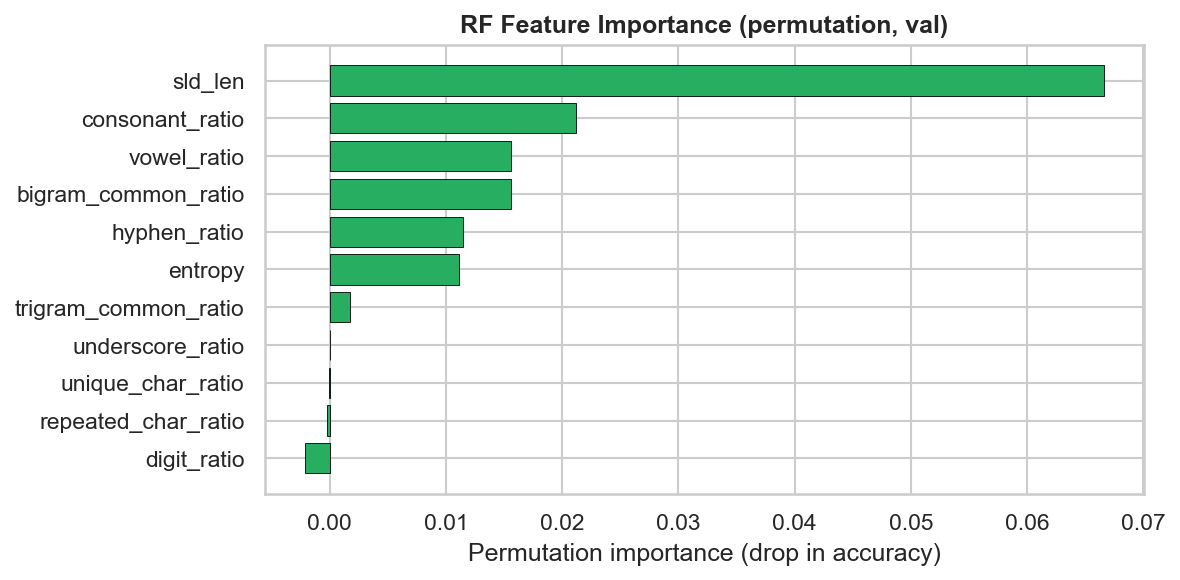

<Figure size 960x720 with 0 Axes>

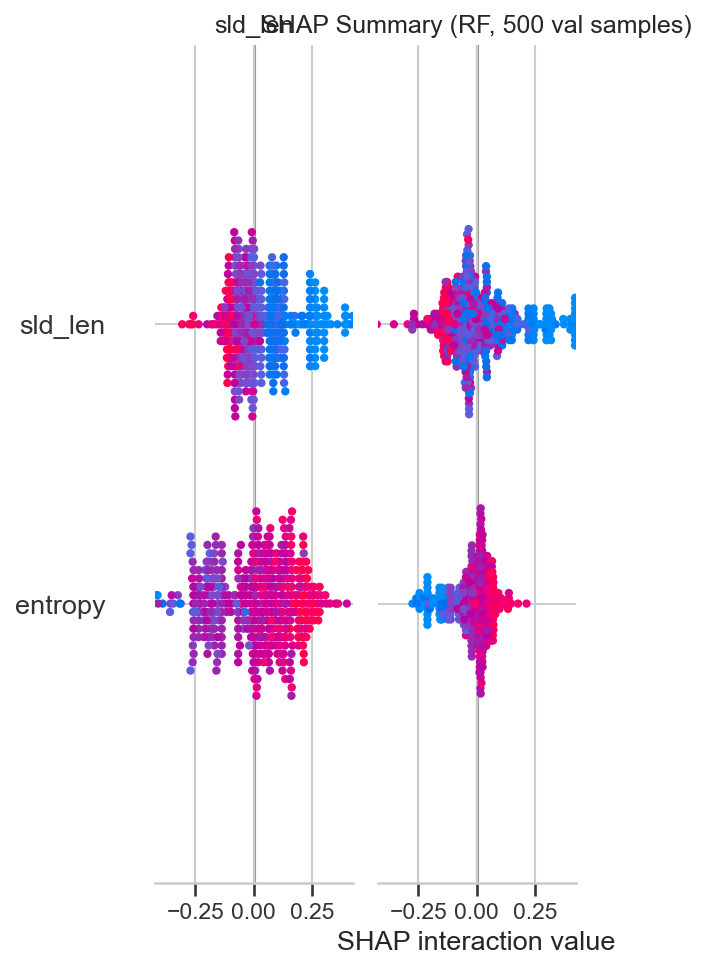

SHAP saved
             feature  impurity  permutation
             sld_len    0.1840       0.0666
     consonant_ratio    0.1241       0.0212
         vowel_ratio    0.1636       0.0156
 bigram_common_ratio    0.1633       0.0156
        hyphen_ratio    0.0506       0.0115
             entropy    0.1645       0.0111
trigram_common_ratio    0.0220       0.0018
    underscore_ratio    0.0001       0.0000
   unique_char_ratio    0.0389      -0.0001
 repeated_char_ratio    0.0409      -0.0003
         digit_ratio    0.0480      -0.0022


In [7]:

# Impurity importance
imp=model.feature_importances_
order=np.argsort(imp)[::-1]
plt.figure(figsize=(8,4))
plt.barh([FEATURE_COLS[i] for i in order], imp[order], color="#2980b9", edgecolor="black", linewidth=0.4)
plt.xlabel("Impurity importance"); plt.title("RF Feature Importance (impurity)", fontweight="bold")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.savefig(FIG_DIR/"rf_feature_impurity.png", bbox_inches="tight"); plt.show()
print("Top 3 by impurity:", [FEATURE_COLS[i] for i in order[:3]])

# Permutation importance (more honest, on val)
from sklearn.inspection import permutation_importance
perm=permutation_importance(model, X_val, y_val, n_repeats=10, random_state=SEED, n_jobs=-1)
perm_imp=perm.importances_mean
order=np.argsort(perm_imp)[::-1]
plt.figure(figsize=(8,4))
plt.barh([FEATURE_COLS[i] for i in order], perm_imp[order], color="#27ae60", edgecolor="black", linewidth=0.4)
plt.xlabel("Permutation importance (drop in accuracy)"); plt.title("RF Feature Importance (permutation, val)", fontweight="bold")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.savefig(FIG_DIR/"rf_feature_permutation.png", bbox_inches="tight"); plt.show()

# SHAP summary (500 samples, shows direction)
try:
    import shap
    explainer=shap.TreeExplainer(model)
    shap_vals=explainer.shap_values(X_val[:500])
    if isinstance(shap_vals,list): shap_vals=shap_vals[1]
    plt.figure()
    shap.summary_plot(shap_vals, X_val[:500], feature_names=FEATURE_COLS, show=False, plot_size=(8,4))
    plt.title("SHAP Summary (RF, 500 val samples)"); plt.tight_layout()
    plt.savefig(FIG_DIR/"rf_shap.png", bbox_inches="tight"); plt.show()
    print("SHAP saved")
except Exception as e:
    print(f"SHAP skipped: {e}")

# Save feature table
import pandas as pd
feat_df=pd.DataFrame({"feature":FEATURE_COLS, "impurity":imp, "permutation":perm_imp}).sort_values("permutation", ascending=False)
print(feat_df.round(4).to_string(index=False))
feat_df.to_csv(BASE/"results/baselines/rf_feature_importance.csv", index=False)



## 5. Save Best Weights & Metrics
We save the single fit as `best` — val is new families, so this *is* the generalization checkpoint. Final test will load this file.


In [8]:

import joblib, json
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

metrics={
    "model":"rf",
    "train":{"acc":float(accuracy_score(y_train,y_pred_train)),"f1":float(f1_score(y_train,y_pred_train)),"auc":float(roc_auc_score(y_train,y_proba_train)),"ap":float(average_precision_score(y_train,y_proba_train))},
    "val":{"acc":float(accuracy_score(y_val,y_pred_val)),"f1":float(f1_score(y_val,y_pred_val)),"auc":float(roc_auc_score(y_val,y_proba_val)),"ap":float(average_precision_score(y_val,y_proba_val)),"wordlist_macro_recall":float(np.mean([(y_pred_val[val["family"]==f]==1).mean() for f in ["suppobox","bigviktor","manuelita"]]))},
    "per_family_val_recall":{f:float((y_pred_val[val["family"]==f]==1).mean()) for f in sorted(val["family"].unique()) if f!="legit"},
    "feature_cols":FEATURE_COLS
}
Path("results/baselines").mkdir(parents=True, exist_ok=True)
with open("results/baselines/rf_metrics.json","w") as f: json.dump(metrics,f,indent=2)
joblib.dump({"model":model, "feature_cols":FEATURE_COLS}, WEIGHTS_DIR/"rf_best.pkl")
joblib.dump({"model":model, "feature_cols":FEATURE_COLS}, BASE/"results/baselines/rf_best.pkl")
print(f"Saved weights to {WEIGHTS_DIR/'rf_best.pkl'} and metrics to results/baselines/rf_metrics.json")
print(json.dumps(metrics,indent=2))


Saved weights to G:\dga_killer\training\weights\rf_best.pkl and metrics to results/baselines/rf_metrics.json
{
  "model": "rf",
  "train": {
    "acc": 0.85159,
    "f1": 0.8475579066303733,
    "auc": 0.9350134039868387,
    "ap": 0.9438226864023749
  },
  "val": {
    "acc": 0.6657638136511376,
    "f1": 0.5960618421715265,
    "auc": 0.6809360610036668,
    "ap": 0.7434066504612609,
    "wordlist_macro_recall": 0.21769743204935801
  },
  "per_family_val_recall": {
    "bigviktor": 0.2745,
    "kraken": 0.427,
    "manuelita": 0.18459229614807404,
    "ranbyus": 0.8815,
    "suppobox": 0.194,
    "zeus-newgoz": 0.9975
  },
  "feature_cols": [
    "sld_len",
    "entropy",
    "digit_ratio",
    "hyphen_ratio",
    "underscore_ratio",
    "vowel_ratio",
    "consonant_ratio",
    "bigram_common_ratio",
    "trigram_common_ratio",
    "unique_char_ratio",
    "repeated_char_ratio"
  ]
}



## Conclusion

- RF was trained on **train only** (32 families), validated on **6 new families** — no leakage.
- All curves/matrices for both train and val are above (confusion, ROC, PR, per-family recall).
- Feature importance shows which lexical numbers matter (usually `entropy` + `sld_len` on top) — answers teacher’s “are lexical features needed? Yes for RF, not for deep nets.”
- Best weights frozen for final one-shot test (`06_Final_Test.ipynb` will load `rf_best.pkl`).

Next: `02_xgboost_baseline.ipynb` (same setup, GPU).
